## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [23]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Using all orb-weavers

98 species total, 44 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.49, Stddev: 1.55, Count of HOGs: 9490
Log odds ratios of DUPLICATION: 
 Mean: 0.08, Stddev: 1.14, Count of HOGs: 12096

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 95 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [05:53<00:00, 28.25it/s]


Permulation counter for MEANS:
 Loss: 2075, Duplication: 2229
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 95
Analysis run on 2026-04-14 at 13:18:43
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 9490 (loss), 12096 (duplication)
Total species: 98
Foreground count: 44
Background count: 54
True mean, loss: -0.486
True standard deviation, loss: 1.547
True mean, duplication: 0.079
True standard deviation, duplication: 1.136

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.207
Probability that the null is true for MEAN, duplication (alt=greater): 0.223

Permulated average mean, loss: -0.006
Permulated average s

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list.txt, background_list_filename=None), min_occ=30, permulation_reps=10000)

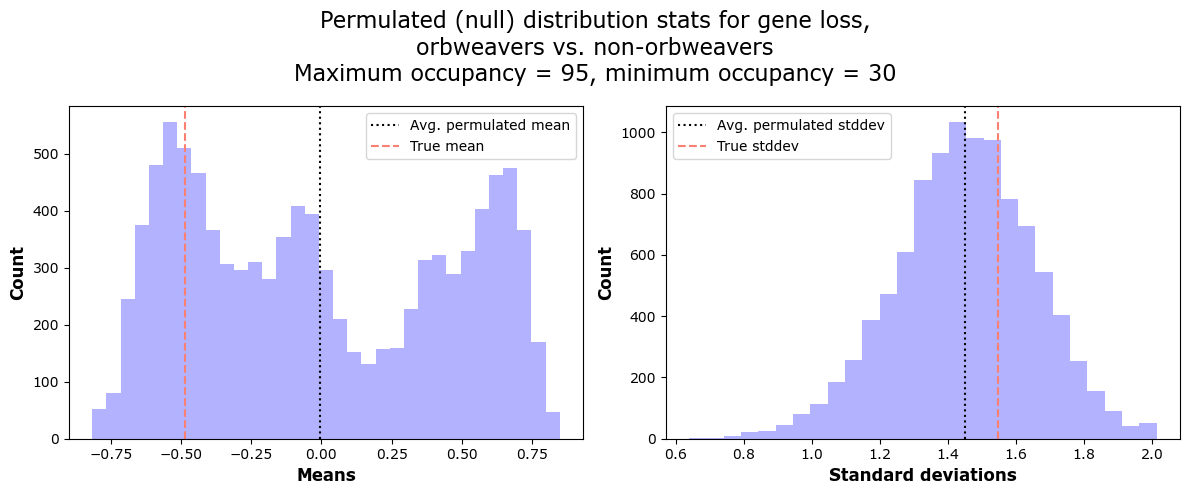

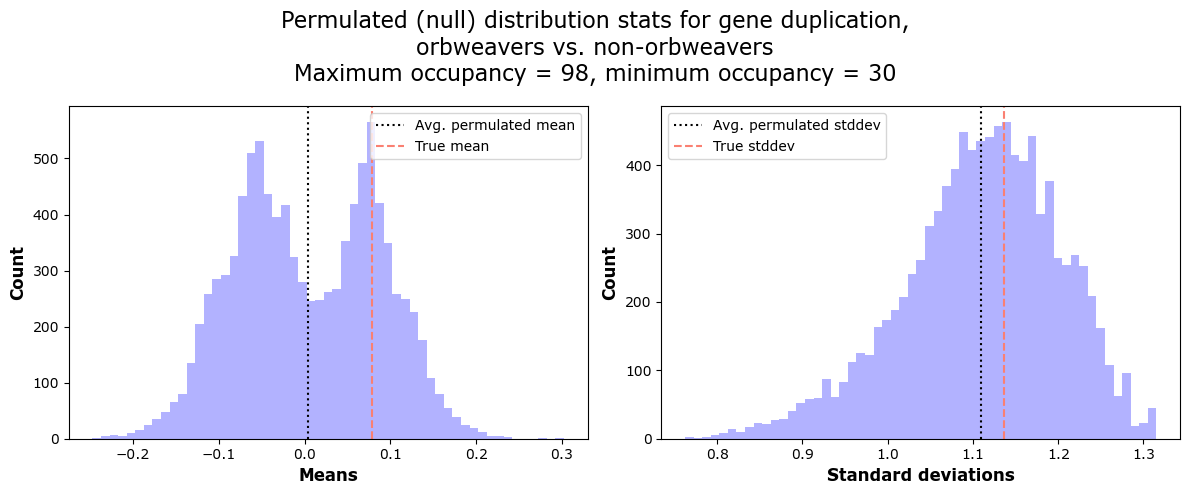

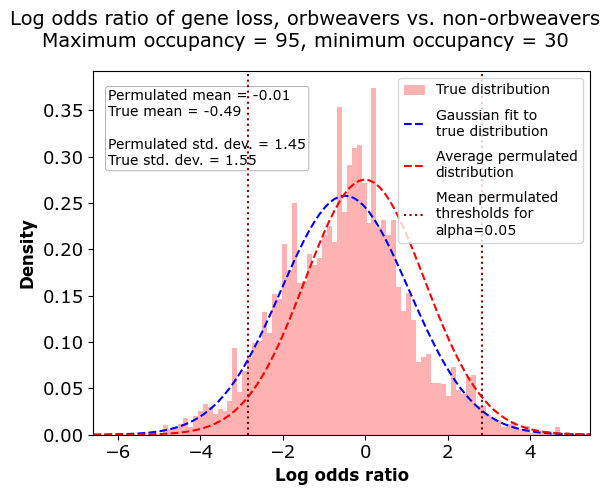

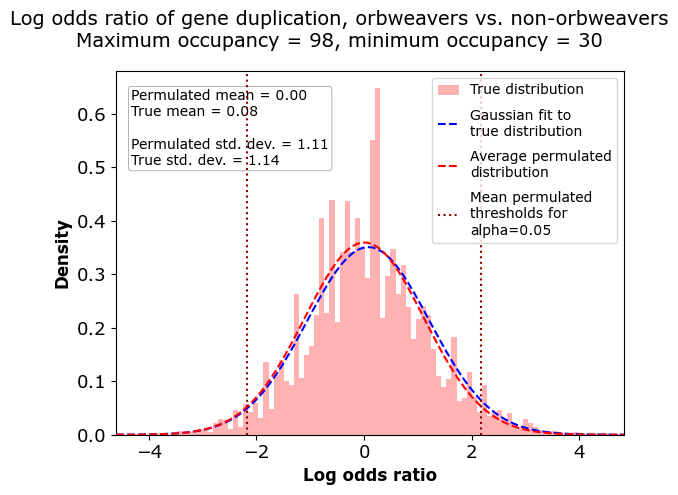

In [10]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=95,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    dir_suffix='all_orb'
)

## Without Araneids

68 species total, 17 foreground, 51 background
Log odds ratios of LOSS: 
 Mean: -0.30, Stddev: 1.61, Count of HOGs: 5973
Log odds ratios of DUPLICATION: 
 Mean: 0.23, Stddev: 1.11, Count of HOGs: 8837

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 65 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [04:59<00:00, 33.36it/s]


Permulation counter for MEANS:
 Loss: 4518, Duplication: 986
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 65
Analysis run on 2026-04-14 at 13:25:28
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list-no-araneids.txt
Background list: /Users/calvin/orb-selection/data/non-orb-weavers-no-araneids.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5973 (loss), 8837 (duplication)
Total species: 68
Foreground count: 17
Background count: 51
True mean, loss: -0.299
True standard deviation, loss: 1.606
True mean, duplication: 0.232
True standard deviation, duplication: 1.108

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.452
Probability that the null is true for MEAN, 

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list-no-araneids.txt, background_list_filename=/Users/calvin/orb-selection/data/non-orb-weavers-no-araneids.txt), min_occ=30, permulation_reps=10000)

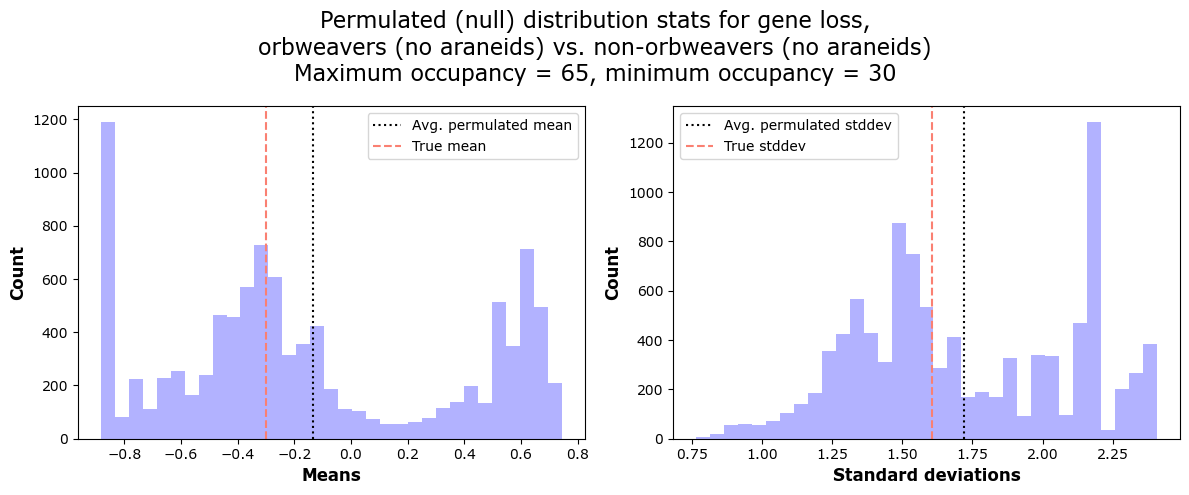

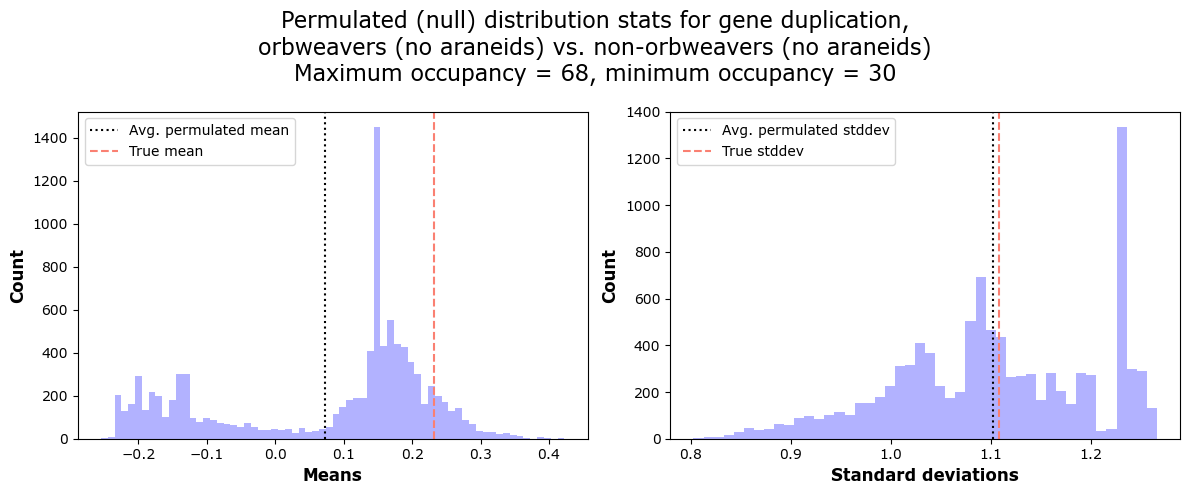

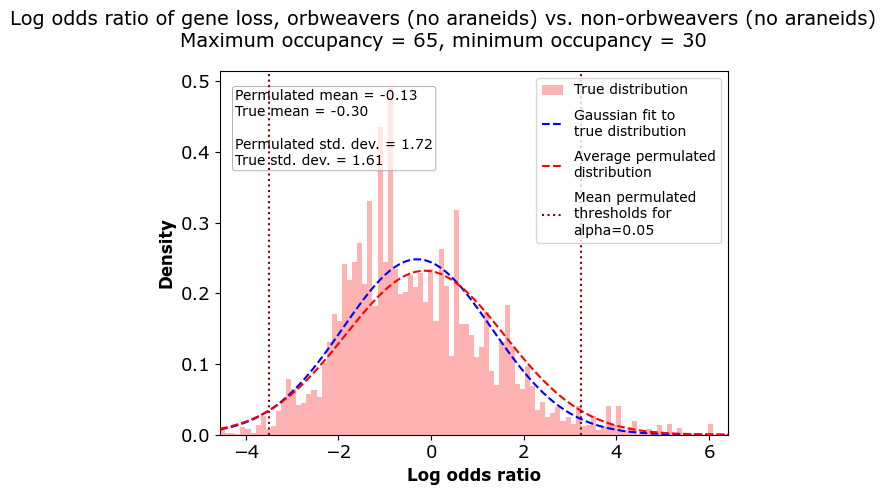

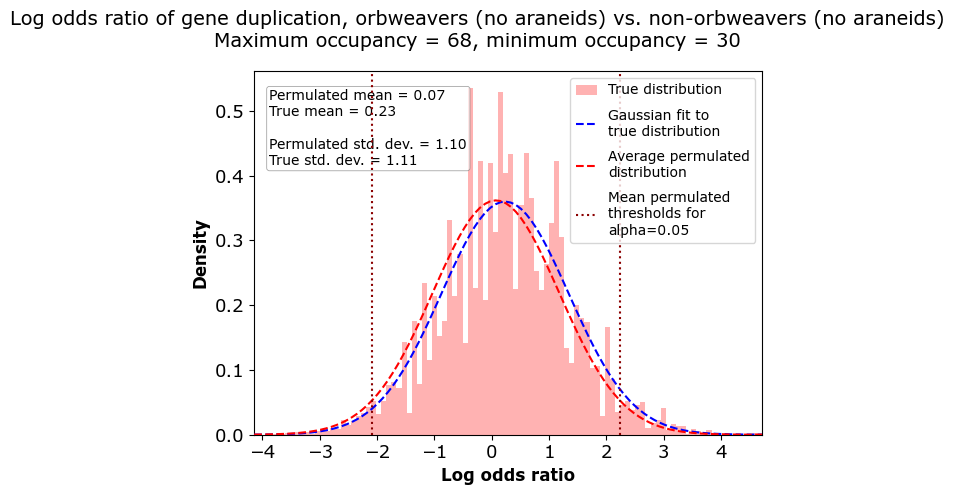

In [11]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=65,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no araneids)',
    bg_name='non-orbweavers (no araneids)',
    foreground_list_filename="data/orbweavers-list-no-araneids.txt",
    background_list_filename="data/non-orb-weavers-no-araneids.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_ara.csv",
    dir_suffix='no_ara'
)

## Without Tetragnathids

84 species total, 30 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.67, Stddev: 1.82, Count of HOGs: 8108
Log odds ratios of DUPLICATION: 
 Mean: 0.05, Stddev: 1.25, Count of HOGs: 10878

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 81 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [05:35<00:00, 29.77it/s]


Permulation counter for MEANS:
 Loss: 4361, Duplication: 3746
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 81
Analysis run on 2026-04-14 at 13:31:16
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list-no-tetragnathids.txt
Background list: /Users/calvin/orb-selection/data/non-orb-weavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 8108 (loss), 10878 (duplication)
Total species: 84
Foreground count: 30
Background count: 54
True mean, loss: -0.674
True standard deviation, loss: 1.817
True mean, duplication: 0.050
True standard deviation, duplication: 1.252

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.436
Probability that the null is true for MEAN, 

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list-no-tetragnathids.txt, background_list_filename=/Users/calvin/orb-selection/data/non-orb-weavers-list.txt), min_occ=30, permulation_reps=10000)

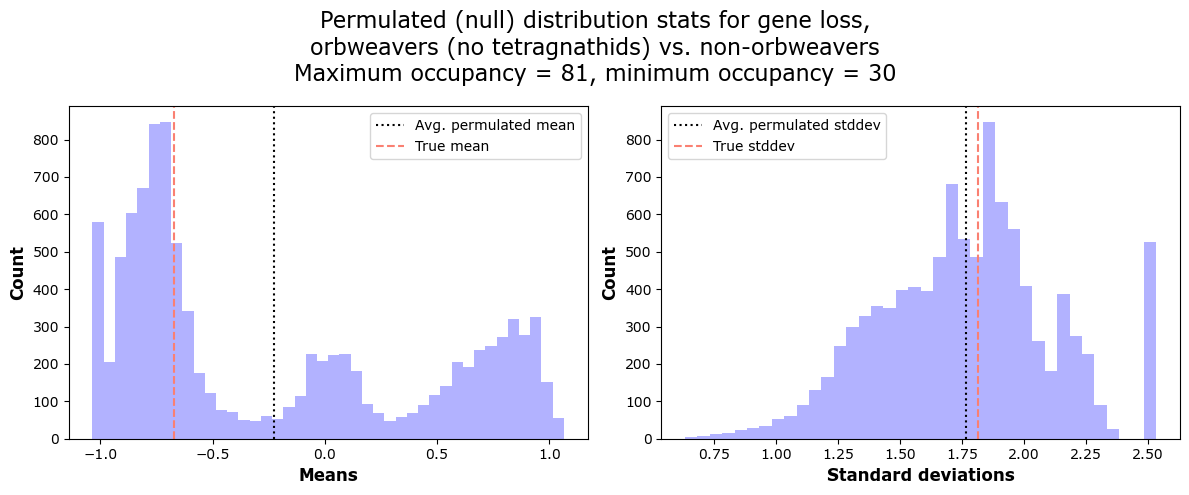

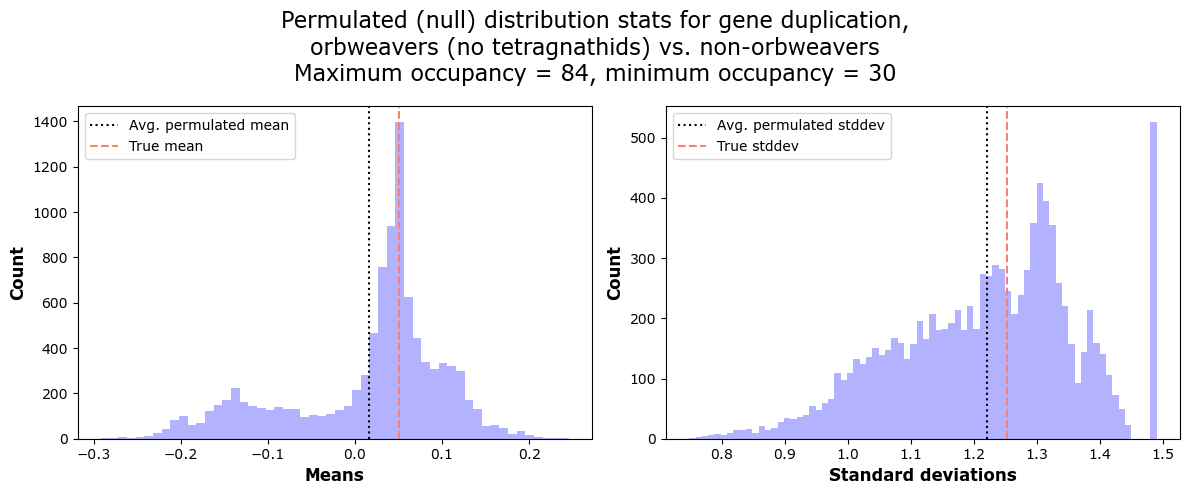

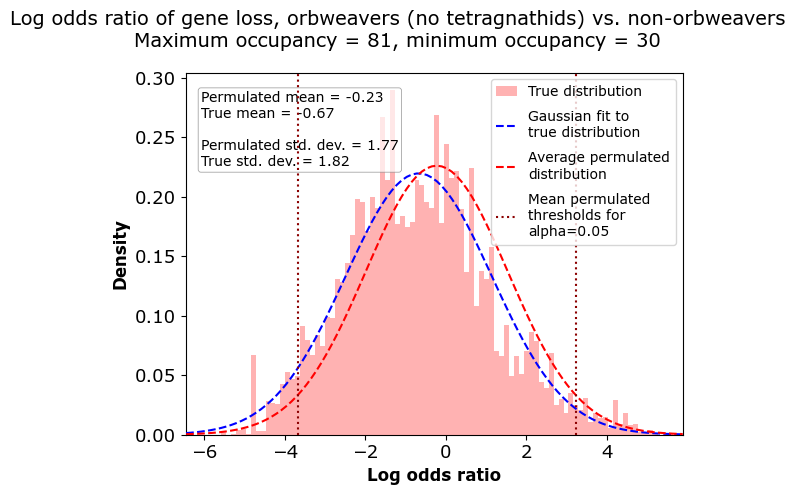

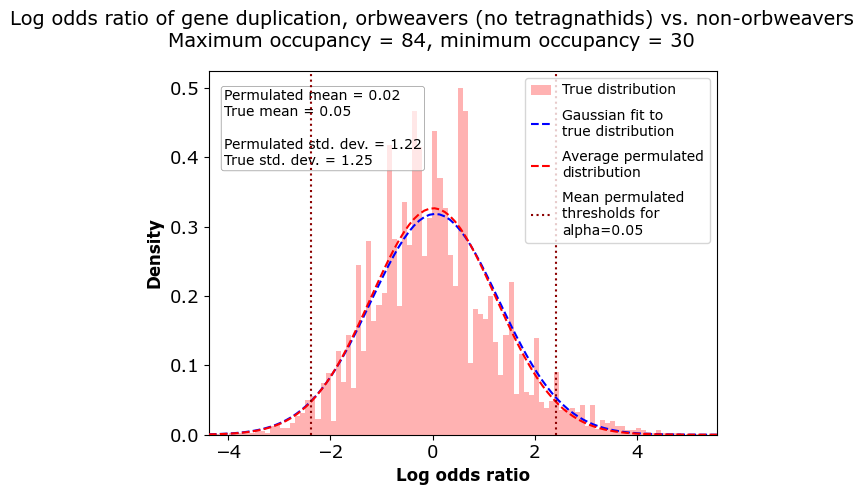

In [12]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=81,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-tetragnathids.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_tet.csv",
    dir_suffix='no_tet'
)

In [28]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr14/Run1_occ_30-95_10000x_all_orb/results.pkl"
)
run1_df = results_all.results_fltrd_df_all
run1_df.loc[run1_df.index[run1_df.index.duplicated()]]

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0006965,62,-2.878486,2.634009,0.9359,0.0641,0.0211,0.9789,False
N5.HOG0006965,62,-2.878486,2.634009,0.9359,0.0641,0.0211,0.9789,True
N5.HOG0007702,42,-2.870699,3.593198,0.9471,0.0529,0.0123,0.9877,False
N5.HOG0007702,42,-2.870699,3.593198,0.9471,0.0529,0.0123,0.9877,True
N5.HOG0007812,71,-4.406222,3.240331,0.9916,0.0084,0.0737,0.9263,True
...,...,...,...,...,...,...,...,...
N5.HOG0064091,30,4.606059,-2.254850,0.0262,0.9738,0.9032,0.0965,False
N5.HOG0069593,46,4.249387,-3.172736,0.0526,0.9474,0.9618,0.0382,False
N5.HOG0069593,46,4.249387,-3.172736,0.0526,0.9474,0.9618,0.0382,True


In [30]:
dfs, counts, df_all, total_count = results_all.filter_for_permulation_hits(min_occ=30, max_occ=95)

In [ ]:
df_all

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test,Significant by confidence interval
HOG,,,,,,,,,
N5.HOG0000276,30,-3.1350438170534196,0.23032406264732208,0.7295,0.2705,0.4794,0.5206,,loss_bg
N5.HOG0001609,49,-2.8415866828425416,2.3914853308298487,0.9605,0.0395,0.0747,0.9253,,dup_fg
N5.HOG0001627,33,2.048042501668181,-4.020456662035705,0.0449,0.9551,0.9745,0.0253,dup_bg,dup_bg
N5.HOG0001633,43,1.448629122343772,-2.5799621727729045,0.1301,0.8699,0.9032,0.0968,,dup_bg
N5.HOG0002031,46,-3.8236010086737187,1.8546381292872387,0.9996,0.0004,0.3311,0.6686,loss_bg,loss_bg
...,...,...,...,...,...,...,...,...,...
N5.HOG0073251,33,-3.4342949103016136,1.6568528896089827,0.9866,0.0134,0.2178,0.7822,loss_bg,loss_bg
N5.HOG0073267,31,-2.8622043155011174,0.7187802976176365,0.708,0.292,0.4392,0.5608,,loss_bg
N5.HOG0073332,32,-3.3240609407250568,0.22636010348081204,0.9239,0.0761,0.4871,0.5129,,loss_bg


In [19]:
%autoreload 2
results_no_ara = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr14/Run2_occ_30-65_10000x_no_ara/results.pkl"
)
run2_df = results_no_ara.results_fltrd_df_all
run2_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0002072,48,3.353081,0.124412,0.0331,0.9563,0.3444,0.6450,True
N5.HOG0005532,57,3.842638,0.668708,0.0246,0.9647,0.0496,0.9398,True
N5.HOG0007439,30,3.853975,-2.616713,0.0097,0.9796,0.8399,0.1495,True
N5.HOG0007845,49,4.196621,-2.796581,0.0031,0.9863,0.9163,0.0731,True
N5.HOG0010634,55,4.331416,-0.912238,0.1227,0.8662,0.7615,0.2279,False
...,...,...,...,...,...,...,...,...
N5.HOG0068730,42,3.089506,-2.436155,0.0115,0.9779,0.8793,0.1100,False
N5.HOG0069974,39,-1.051603,-2.529815,0.4936,0.4958,0.6396,0.3497,False
N5.HOG0070676,30,2.023407,-2.700745,0.1090,0.8803,0.7568,0.2325,False


In [20]:
%autoreload 2
results_no_tet = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr14/Run3_occ_30-81_10000x_no_tet/results.pkl"
)
run3_df = results_no_tet.results_fltrd_df_all
run3_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0001041,40,3.263230,-0.857170,0.0010,0.9990,0.7992,0.2008,True
N5.HOG0002072,50,3.453174,-0.391856,0.0873,0.9127,0.7998,0.2002,False
N5.HOG0004196,34,3.356732,-1.479114,0.2834,0.7165,0.8048,0.1952,False
N5.HOG0007439,30,4.267289,-3.107778,0.0182,0.9818,0.8627,0.1373,True
N5.HOG0007639,50,3.908429,-1.396016,0.3237,0.6761,0.7336,0.2664,False
...,...,...,...,...,...,...,...,...
N5.HOG0071484,30,0.849227,-2.643093,0.0980,0.9020,0.8579,0.1421,False
N5.HOG0071758,38,2.643444,-2.433024,0.4053,0.5945,0.8344,0.1655,False
N5.HOG0071948,33,1.338423,-2.548809,0.3790,0.6210,0.8561,0.1439,False


In [21]:
common_hogs = run1_df.index.intersection(run2_df.index).intersection(run3_df.index)
intersection_df = run1_df.loc[common_hogs]
intersection_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0002072,52,3.473733,-0.762726,0.0108,0.9892,0.7989,0.2011,True
N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True
N5.HOG0010634,55,4.393024,-1.824667,0.0855,0.9145,0.8897,0.1103,False
N5.HOG0012951,42,4.427061,-3.392096,0.0438,0.9562,0.9630,0.0369,True
N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True
...,...,...,...,...,...,...,...,...
N5.HOG0062680,98,0.207736,-3.113861,0.4018,0.5981,0.9679,0.0320,True
N5.HOG0063867,83,2.825520,-2.917895,0.1753,0.8247,0.9623,0.0376,True
N5.HOG0067099,56,2.637281,-2.916448,0.0624,0.9376,0.9541,0.0458,True


In [ ]:
run1_df_fltrd = run1_df[
    run1_df["Significant in permulation test"]
]
run2_df_fltrd = run2_df[
    run2_df["Significant in permulation test"]
]
run3_df_fltrd = run3_df[
    run3_df["Significant in permulation test"]
]

common_hogs_fltrd = run1_df_fltrd.index.intersection(run2_df_fltrd.index).intersection(run3_df_fltrd.index)
intersection_df_fltrd = run1_df_fltrd.loc[common_hogs_fltrd]
intersection_df_fltrd

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True
N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True
N5.HOG0022325,34,3.812024,-3.426032,0.0075,0.9925,0.9656,0.0343,True
N5.HOG0033305,33,4.870321,-3.217480,0.0076,0.9924,0.9439,0.0559,True
N5.HOG0036007,31,4.719117,-1.588599,0.0065,0.9935,0.8698,0.1301,True
N5.HOG0043760,35,5.023451,-3.020487,0.0046,0.9954,0.9393,0.0603,True
N5.HOG0043831,30,4.644039,-1.832478,0.0113,0.9887,0.8984,0.1016,True
N5.HOG0047981,33,4.863396,-3.558733,0.0044,0.9956,0.9581,0.0418,True
N5.HOG0048549,61,4.353531,-1.561977,0.0001,0.9999,0.9176,0.0824,True


Of interest: innexin, slit, osteopetrosis-associated transmembrane protein (nervous), pantetheinase (oxidative stress)

Makes sense that the ones that are more likely lost in orb-weavers and more likely duplicated in non-orb-weavers are unannotated in U.div! Maybe I should annotate them using a non-orb-weaver genome

In [17]:
convert_hogs_to_locs(intersection_df, results_all.true_odds.hog_node_genes_tsv)

Processing HOGs: 100%|██████████| 26/26 [00:00<00:00, 1804.84it/s]


,HOG,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test,udiv_genes,dmel_orthologs,LOC,txpt,GO_terms,Description
0,N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True,,,NaN,NaN,NaN,NaN
1,N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True,,,NaN,NaN,NaN,NaN
2,N5.HOG0022325,34,3.812024,-3.426032,0.0075,0.9925,0.9656,0.0343,True,,,NaN,NaN,NaN,NaN
3,N5.HOG0033305,33,4.870321,-3.217480,0.0076,0.9924,0.9439,0.0559,True,,,NaN,NaN,NaN,NaN
4,N5.HOG0036007,31,4.719117,-1.588599,0.0065,0.9935,0.8698,0.1301,True,,,NaN,NaN,NaN,NaN
5,N5.HOG0043760,35,5.023451,-3.020487,0.0046,0.9954,0.9393,0.0603,True,,,NaN,NaN,NaN,NaN
6,N5.HOG0043831,30,4.644039,-1.832478,0.0113,0.9887,0.8984,0.1016,True,,,NaN,NaN,NaN,NaN
7,N5.HOG0047981,33,4.863396,-3.558733,0.0044,0.9956,0.9581,0.0418,True,,,NaN,NaN,NaN,NaN
8,N5.HOG0048549,61,4.353531,-1.561977,0.0001,0.9999,0.9176,0.0824,True,,,NaN,NaN,NaN,NaN
9,N5.HOG0054184,31,4.717420,-4.019122,0.0088,0.9912,0.9551,0.0445,True,,,NaN,NaN,NaN,NaN
